In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import zipfile

zip_path = '/content/drive/MyDrive/emotion_recognition_task_bcs_secy_recruitment.zip'

extract_path = '/content/emotion_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

BASE = f'{extract_path}/emotion_recognition_task'

print(os.listdir(BASE))

df = pd.read_csv(f'{BASE}/emotion_configs.csv')

print(df.head())
print(df.shape)
print(df['emotion'].value_counts())

Mounted at /content/drive
['emotion_recognition_task']
['emotion_configs.csv', 'embeddings', 'audio']
   subject  trial  emotion_num  emotion           audio_wav_filepath  \
0        1      3           10      sad  audio/s01/t003/s01_t003.wav   
1        1      9           14  neutral  audio/s01/t009/s01_t009.wav   
2        1     14            2    anger  audio/s01/t014/s01_t014.wav   
3        1     15            4  disgust  audio/s01/t015/s01_t015.wav   
4        1     27           10      sad  audio/s01/t027/s01_t027.wav   

                          brain_embedding_filepath  embedding_dim  
0  embeddings/s01/t003/cbramod_trial_embedding.npy            200  
1  embeddings/s01/t009/cbramod_trial_embedding.npy            200  
2  embeddings/s01/t014/cbramod_trial_embedding.npy            200  
3  embeddings/s01/t015/cbramod_trial_embedding.npy            200  
4  embeddings/s01/t027/cbramod_trial_embedding.npy            200  
(500, 7)
emotion
disgust     80
happy       79
neutral   

In [ ]:

def get_audio_path(row):
    s = f"s{int(row['subject']):02d}"
    t = f"t{int(row['trial']):03d}"
    return f"{BASE}/audio/{s}/{t}/{s}_{t}.wav"

def get_embedding_path(row):
    s = f"s{int(row['subject']):02d}"
    t = f"t{int(row['trial']):03d}"
    return f"{BASE}/embeddings/{s}/{t}/cbramod_trial_embedding.npy"

df['audio_path'] = df.apply(get_audio_path, axis=1)
df['eeg_path'] = df.apply(get_embedding_path, axis=1)

# Sanity check — all files exist?
missing_audio = df[~df['audio_path'].apply(os.path.exists)]
missing_eeg = df[~df['eeg_path'].apply(os.path.exists)]

print(f"Missing audio files: {len(missing_audio)}")
print(f"Missing EEG files: {len(missing_eeg)}")

Missing audio files: 0
Missing EEG files: 0


In [ ]:
!pip install torchvggish librosa scikit-learn -q

import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.9 MB/s eta 0:00:00
GPU available: False
Device: CPU


In [ ]:

import torch
from torchvggish import vggish, vggish_input

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = vggish()
model.eval()
model.to(device)
model.postprocess = False

print(" VGGish loaded!")

Device: cpu
Downloading: "https://github.com/harritaylor/torchvggish/releases/download/v0.1/vggish_pca_params-970ea276.pth" to /root/.cache/torch/hub/checkpoints/vggish_pca_params-970ea276.pth


100%|██████████| 177k/177k [00:00<00:00, 2.73MB/s]


Downloading: "https://github.com/harritaylor/torchvggish/releases/download/v0.1/vggish-10086976.pth" to /root/.cache/torch/hub/checkpoints/vggish-10086976.pth


100%|██████████| 275M/275M [00:05<00:00, 53.7MB/s]


 VGGish loaded!


In [ ]:

test_wav = df['audio_path'].iloc[0]
example = vggish_input.wavfile_to_examples(test_wav)
example = example.float().to(device)
print(f"Input shape: {example.shape}")

with torch.no_grad():
    embedding = model(example)

print(f"Output shape: {embedding.shape}")

Input shape: torch.Size([5, 1, 96, 64])
Output shape: torch.Size([5, 128])
✅ Working!


In [ ]:

from tqdm import tqdm
import numpy as np
import os

audio_embeddings = []
eeg_embeddings = []
labels = []
sample_ids = []
failed = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:

        example = vggish_input.wavfile_to_examples(row['audio_path'])
        example = example.float().to(device)

        with torch.no_grad():
            emb = model(example)

        audio_emb = emb.mean(dim=0).cpu().numpy()

        eeg_emb = np.load(row['eeg_path']).flatten()[:200]

        audio_embeddings.append(audio_emb)
        eeg_embeddings.append(eeg_emb)
        labels.append(row['emotion'])
        sample_ids.append(idx)

    except Exception as e:
        print(f"Failed at idx {idx}: {e}")
        failed.append(idx)

audio_embeddings = np.array(audio_embeddings)
eeg_embeddings = np.array(eeg_embeddings)
labels = np.array(labels)

print(f"Audio embeddings: {audio_embeddings.shape}")
print(f"EEG embeddings:   {eeg_embeddings.shape}")
print(f"Labels:           {labels.shape}")
print(f"Failed:           {len(failed)}")

os.makedirs('/content/drive/MyDrive/echo_outputs', exist_ok=True)
np.save('/content/drive/MyDrive/echo_outputs/audio_embeddings.npy', audio_embeddings)
np.save('/content/drive/MyDrive/echo_outputs/eeg_embeddings.npy', eeg_embeddings)
np.save('/content/drive/MyDrive/echo_outputs/labels.npy', labels)
print(" Saved to Drive!")

100%|██████████| 500/500 [04:47<00:00,  1.74it/s]


Audio embeddings: (500, 128)
EEG embeddings:   (500, 200)
Labels:           (500,)
Failed:           0
✅ Saved to Drive!


Class distribution:
  anger: 54
  disgust: 80
  fear: 62
  happy: 79
  neutral: 78
  sad: 70
  surprise: 77

Audio emb — min: 0.000, max: 1.062, mean: 0.117
EEG emb   — min: -0.645, max: 0.497, mean: 0.007


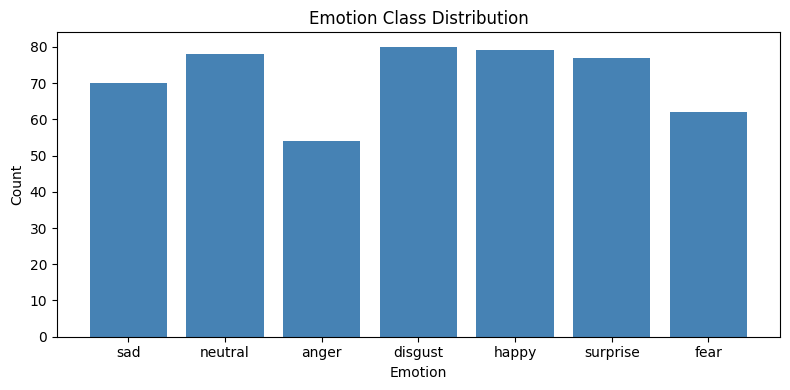

In [ ]:

import matplotlib.pyplot as plt
from collections import Counter

label_counts = Counter(labels)
print("Class distribution:")
for emotion, count in sorted(label_counts.items()):
    print(f"  {emotion}: {count}")

print(f"\nAudio emb — min: {audio_embeddings.min():.3f}, max: {audio_embeddings.max():.3f}, mean: {audio_embeddings.mean():.3f}")
print(f"EEG emb   — min: {eeg_embeddings.min():.3f}, max: {eeg_embeddings.max():.3f}, mean: {eeg_embeddings.mean():.3f}")

plt.figure(figsize=(8,4))
plt.bar(label_counts.keys(), label_counts.values(), color='steelblue')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import Counter

train_mask = df['subject'].isin(range(1, 9))
val_mask   = df['subject'].isin([9])
test_mask  = df['subject'].isin([10, 11])

X_audio_train_raw = audio_embeddings[train_mask]
X_audio_val_raw   = audio_embeddings[val_mask]
X_audio_test_raw  = audio_embeddings[test_mask]

X_eeg_train_raw   = eeg_embeddings[train_mask]
X_eeg_val_raw     = eeg_embeddings[val_mask]
X_eeg_test_raw    = eeg_embeddings[test_mask]

audio_scaler = StandardScaler()
X_audio_train = audio_scaler.fit_transform(X_audio_train_raw)
X_audio_val   = audio_scaler.transform(X_audio_val_raw)
X_audio_test  = audio_scaler.transform(X_audio_test_raw)

eeg_scaler = StandardScaler()
X_eeg_train = eeg_scaler.fit_transform(X_eeg_train_raw)
X_eeg_val   = eeg_scaler.transform(X_eeg_val_raw)
X_eeg_test  = eeg_scaler.transform(X_eeg_test_raw)

le = LabelEncoder()
y_train = le.fit_transform(labels[train_mask])
y_val   = le.transform(labels[val_mask])
y_test  = le.transform(labels[test_mask])

print(f"Train: {X_audio_train.shape[0]} samples")
print(f"Val:   {X_audio_val.shape[0]} samples")
print(f"Test:  {X_audio_test.shape[0]} samples")
print(f"\nTrain dist: {Counter(le.inverse_transform(y_train))}")
print(f"Val dist:   {Counter(le.inverse_transform(y_val))}")
print(f"Test dist:  {Counter(le.inverse_transform(y_test))}")

Train: 382 samples
Val:   48 samples
Test:  70 samples

Train dist: Counter({np.str_('disgust'): 65, np.str_('happy'): 60, np.str_('surprise'): 59, np.str_('neutral'): 57, np.str_('sad'): 53, np.str_('anger'): 44, np.str_('fear'): 44})
Val dist:   Counter({np.str_('fear'): 9, np.str_('sad'): 9, np.str_('disgust'): 8, np.str_('surprise'): 7, np.str_('happy'): 6, np.str_('neutral'): 5, np.str_('anger'): 4})
Test dist:  Counter({np.str_('neutral'): 16, np.str_('happy'): 13, np.str_('surprise'): 11, np.str_('fear'): 9, np.str_('sad'): 8, np.str_('disgust'): 7, np.str_('anger'): 6})


In [ ]:

audio_embeddings_rich = []
failed = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        example = vggish_input.wavfile_to_examples(row['audio_path'])
        example = example.float().to(device)

        with torch.no_grad():
            emb = model(example)

        emb_mean = emb.mean(dim=0).cpu().numpy()
        emb_std  = emb.std(dim=0).cpu().numpy()
        emb_max  = emb.max(dim=0).values.cpu().numpy()

        rich_emb = np.concatenate([emb_mean, emb_std, emb_max])
        audio_embeddings_rich.append(rich_emb)

    except Exception as e:
        print(f"Failed at idx {idx}: {e}")
        failed.append(idx)
        audio_embeddings_rich.append(np.zeros(384))

audio_embeddings_rich = np.array(audio_embeddings_rich)
print(f"Rich audio embeddings: {audio_embeddings_rich.shape}")

np.save('/content/drive/MyDrive/echo_outputs/audio_embeddings_rich.npy', audio_embeddings_rich)
print(" Saved!")

100%|██████████| 500/500 [04:02<00:00,  2.06it/s]


Rich audio embeddings: (500, 384)
 Saved!


In [ ]:

X_rich_train_raw = audio_embeddings_rich[train_mask]
X_rich_val_raw   = audio_embeddings_rich[val_mask]
X_rich_test_raw  = audio_embeddings_rich[test_mask]

rich_scaler = StandardScaler()
X_rich_train = rich_scaler.fit_transform(X_rich_train_raw)
X_rich_val   = rich_scaler.transform(X_rich_val_raw)
X_rich_test  = rich_scaler.transform(X_rich_test_raw)

print(f"Rich train: {X_rich_train.shape}")
print(f"Rich val:   {X_rich_val.shape}")
print(f"Rich test:  {X_rich_test.shape}")

Rich train: (382, 384)
Rich val:   (48, 384)
Rich test:  (70, 384)


In [ ]:

import torch
from torch.utils.data import DataLoader, TensorDataset

X_rich_train_t = torch.tensor(X_rich_train, dtype=torch.float32).to(device)
X_rich_val_t   = torch.tensor(X_rich_val,   dtype=torch.float32).to(device)
X_rich_test_t  = torch.tensor(X_rich_test,  dtype=torch.float32).to(device)

X_eeg_train_t  = torch.tensor(X_eeg_train,  dtype=torch.float32).to(device)
X_eeg_val_t    = torch.tensor(X_eeg_val,    dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.long).to(device)

train_dataset = TensorDataset(X_rich_train_t, X_eeg_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

print(" Tensors ready!")

 Tensors ready!


In [ ]:

import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))

class ProjectionBlock(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=256, bottleneck_dim=64, output_dim=200, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            ResidualBlock(hidden_dim, dropout),
            nn.Linear(hidden_dim, bottleneck_dim),
            nn.LayerNorm(bottleneck_dim),
            nn.GELU(),
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            ResidualBlock(hidden_dim, dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

class EmotionHead(nn.Module):
    def __init__(self, input_dim=200, num_classes=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

proj  = ProjectionBlock().to(device)
ehead = EmotionHead().to(device)

total_params = sum(p.numel() for p in proj.parameters()) + \
               sum(p.numel() for p in ehead.parameters())
print(f"Total parameters: {total_params:,}")
print(" Models ready!")

Total parameters: 462,735
 Models ready!


In [ ]:

import torch.nn.functional as F

def infonce_loss(audio_proj, eeg_emb, temperature=0.07):
    a = F.normalize(audio_proj, dim=1)
    b = F.normalize(eeg_emb,    dim=1)
    logits = torch.mm(a, b.t()) / temperature
    labels = torch.arange(logits.shape[0]).to(device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels)) / 2

def vicreg_loss(audio_proj, eeg_emb, sim_weight=25, var_weight=25, cov_weight=1):
    N, D = audio_proj.shape
    sim     = F.mse_loss(audio_proj, eeg_emb)
    std_a   = torch.sqrt(audio_proj.var(dim=0) + 1e-4)
    std_b   = torch.sqrt(eeg_emb.var(dim=0)    + 1e-4)
    var_loss = (F.relu(1 - std_a).mean() + F.relu(1 - std_b).mean()) / 2
    a_norm  = audio_proj - audio_proj.mean(dim=0)
    b_norm  = eeg_emb    - eeg_emb.mean(dim=0)
    cov_a   = (a_norm.T @ a_norm) / (N - 1)
    cov_b   = (b_norm.T @ b_norm) / (N - 1)
    cov_loss = (cov_a.fill_diagonal_(0).pow(2).sum() / D +
                cov_b.fill_diagonal_(0).pow(2).sum() / D)
    return sim_weight * sim + var_weight * var_loss + cov_weight * cov_loss

def combined_alignment_loss(audio_proj, eeg_emb, alpha=0.5):
    return alpha * infonce_loss(audio_proj, eeg_emb) + \
           (1 - alpha) * vicreg_loss(audio_proj, eeg_emb)

print("Loss functions ready!")

Loss functions ready!


Joint training (Alignment + Emotion)...
Epoch [ 30/300] Loss: 22.7032 | Val Macro-F1: 0.0873 | Best: 0.1310
Epoch [ 60/300] Loss: 21.6721 | Val Macro-F1: 0.1491 | Best: 0.2080
Epoch [ 90/300] Loss: 21.1987 | Val Macro-F1: 0.1999 | Best: 0.2276

⏹ Early stopping at epoch 99

✅ Done! Best Val Macro-F1: 0.2276


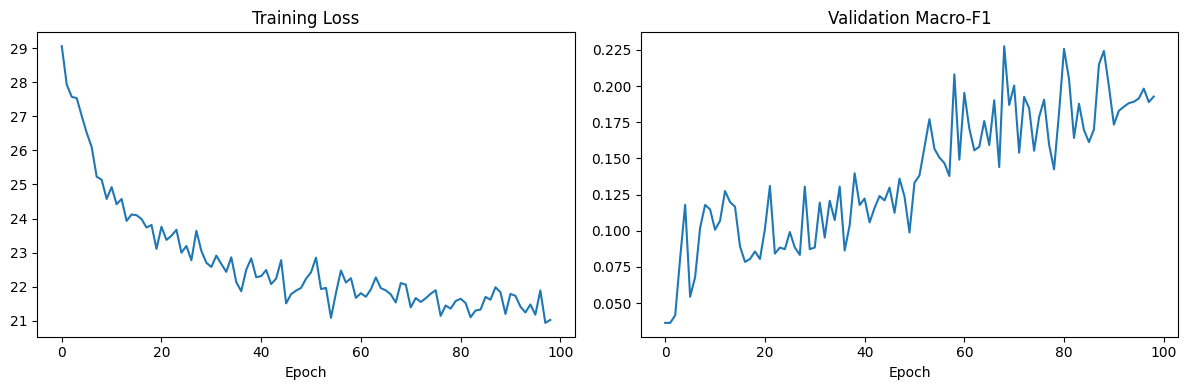

In [ ]:

import torch.optim as optim
from sklearn.metrics import f1_score

optimizer = optim.Adam(
    list(proj.parameters()) + list(ehead.parameters()),
    lr=3e-4, weight_decay=1e-4
)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)
ce_loss      = nn.CrossEntropyLoss()
EPOCHS       = 300
patience     = 30
best_val_f1  = -1
patience_ctr = 0
best_proj_state  = None
best_ehead_state = None
train_losses = []
val_f1s      = []

print("Joint training (Alignment + Emotion)...")

for epoch in range(EPOCHS):
    proj.train()
    ehead.train()
    epoch_loss = 0

    for audio_batch, eeg_batch, label_batch in train_loader:
        optimizer.zero_grad()
        projected  = proj(audio_batch)
        logits     = ehead(projected)
        align_loss = combined_alignment_loss(projected, eeg_batch)
        cls_loss   = ce_loss(logits, label_batch)
        loss       = 0.6 * align_loss + 0.4 * cls_loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    proj.eval()
    ehead.eval()
    with torch.no_grad():
        val_proj   = proj(X_rich_val_t)
        val_logits = ehead(val_proj)
        val_preds  = val_logits.argmax(dim=1).cpu().numpy()
        val_f1     = f1_score(y_val, val_preds, average='macro', zero_division=0)
        val_f1s.append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        patience_ctr     = 0
        best_proj_state  = {k: v.clone() for k, v in proj.state_dict().items()}
        best_ehead_state = {k: v.clone() for k, v in ehead.state_dict().items()}
    else:
        patience_ctr += 1

    if (epoch+1) % 30 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] Loss: {avg_loss:.4f} | Val Macro-F1: {val_f1:.4f} | Best: {best_val_f1:.4f}")

    if patience_ctr >= patience:
        print(f"\n⏹ Early stopping at epoch {epoch+1}")
        break

proj.load_state_dict(best_proj_state)
ehead.load_state_dict(best_ehead_state)
print(f"\n✅ Done! Best Val Macro-F1: {best_val_f1:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax2.plot(val_f1s)
ax2.set_title('Validation Macro-F1')
ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, \
                            ConfusionMatrixDisplay, classification_report
from sklearn.svm import SVC

baseline_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
baseline_clf.fit(X_rich_train, y_train)
base_preds = baseline_clf.predict(X_rich_test)
base_acc   = accuracy_score(y_test, base_preds)
base_mf1   = f1_score(y_test, base_preds, average='macro',    zero_division=0)
base_wf1   = f1_score(y_test, base_preds, average='weighted', zero_division=0)

print(f"\n{'='*45}")
print(f"  Baseline Raw VGGish + SVM")
print(f"{'='*45}")
print(f"  Accuracy:    {base_acc:.4f}")
print(f"  Macro-F1:    {base_mf1:.4f}")
print(f"  Weighted-F1: {base_wf1:.4f}")
print(f"\n{classification_report(y_test, base_preds, target_names=le.classes_, zero_division=0)}")

proj.eval()
ehead.eval()
with torch.no_grad():
    refined_test_np = proj(X_rich_test_t).cpu().numpy()
    logits          = ehead(proj(X_rich_test_t))
    refined_preds   = logits.argmax(dim=1).cpu().numpy()

acc_r = accuracy_score(y_test, refined_preds)
mf1_r = f1_score(y_test, refined_preds, average='macro',    zero_division=0)
wf1_r = f1_score(y_test, refined_preds, average='weighted', zero_division=0)

print(f"\n{'='*45}")
print(f"  Brain-Aligned + Emotion Head")
print(f"{'='*45}")
print(f"  Accuracy:    {acc_r:.4f}")
print(f"  Macro-F1:    {mf1_r:.4f}")
print(f"  Weighted-F1: {wf1_r:.4f}")
print(f"\n{classification_report(y_test, refined_preds, target_names=le.classes_, zero_division=0)}")

print(f"\n{'='*50}")
print(f"{'Metric':<20} {'Baseline':>12} {'Refined':>12} {'Delta':>10}")
print(f"{'='*50}")
print(f"{'Accuracy':<20} {base_acc:>12.4f} {acc_r:>12.4f} {acc_r - base_acc:>+10.4f}")
print(f"{'Macro-F1':<20} {base_mf1:>12.4f} {mf1_r:>12.4f} {mf1_r - base_mf1:>+10.4f}")
print(f"{'Weighted-F1':<20} {base_wf1:>12.4f} {wf1_r:>12.4f} {wf1_r - base_wf1:>+10.4f}")
print(f"{'='*50}")


  Baseline Raw VGGish + SVM
  Accuracy:    0.1857
  Macro-F1:    0.1868
  Weighted-F1: 0.1872

              precision    recall  f1-score   support

       anger       0.25      0.17      0.20         6
     disgust       0.11      0.29      0.16         7
        fear       0.60      0.33      0.43         9
       happy       0.14      0.23      0.17        13
     neutral       0.29      0.12      0.17        16
         sad       0.00      0.00      0.00         8
    surprise       0.17      0.18      0.17        11

    accuracy                           0.19        70
   macro avg       0.22      0.19      0.19        70
weighted avg       0.23      0.19      0.19        70


  Brain-Aligned + Emotion Head
  Accuracy:    0.2286
  Macro-F1:    0.1933
  Weighted-F1: 0.2092

              precision    recall  f1-score   support

       anger       1.00      0.17      0.29         6
     disgust       0.22      0.57      0.32         7
        fear       0.00      0.00      0.00  

/tmp/ipykernel_3777/3022629465.py:15: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3777/3022629465.py:16: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix_comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


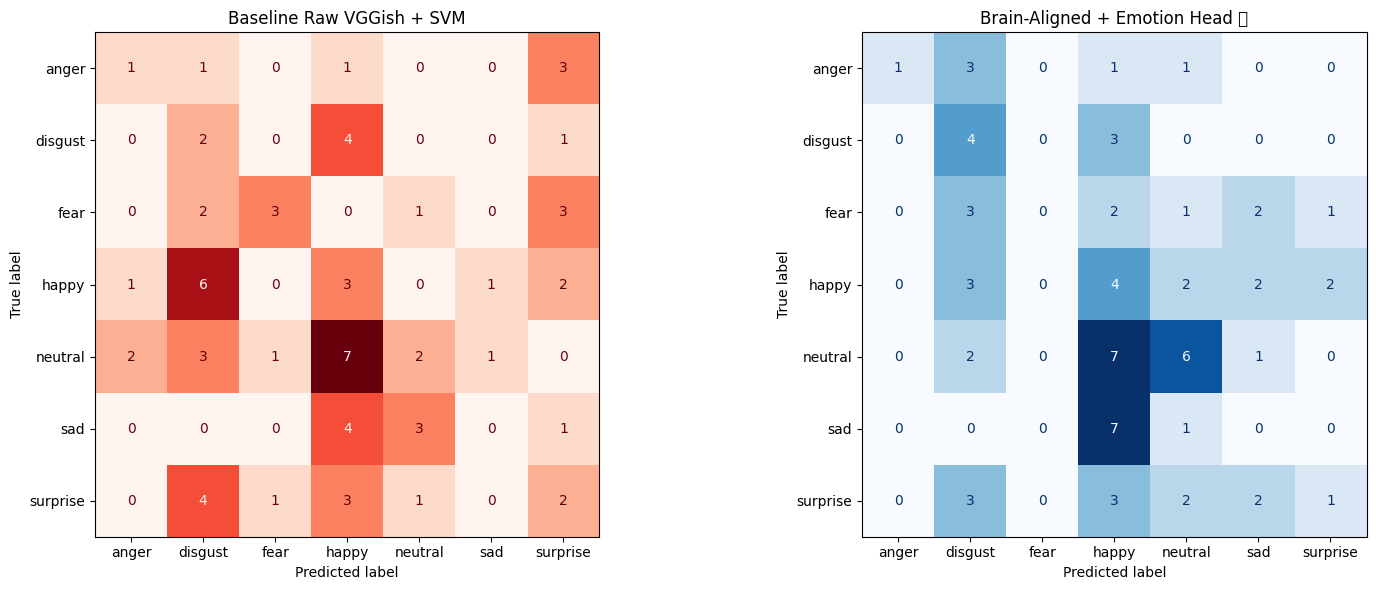

/tmp/ipykernel_3777/3022629465.py:44: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3777/3022629465.py:45: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('tsne_comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


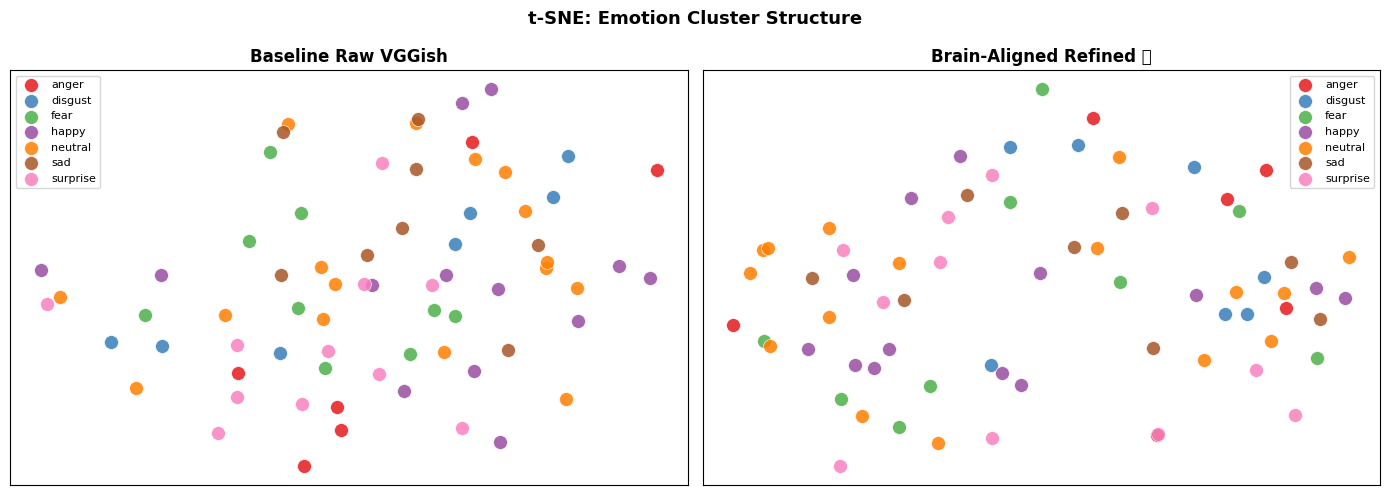

In [ ]:

from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_base = confusion_matrix(y_test, base_preds)
cm_ref  = confusion_matrix(y_test, refined_preds)

ConfusionMatrixDisplay(cm_base, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Baseline Raw VGGish + SVM')

ConfusionMatrixDisplay(cm_ref, display_labels=le.classes_).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Brain-Aligned + Emotion Head ⭐')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150)
plt.show()

proj.eval()
with torch.no_grad():
    refined_train_np = proj(X_rich_train_t).cpu().numpy()
    refined_test_np  = proj(X_rich_test_t).cpu().numpy()

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (X, y, title) in zip(axes, [
    (X_rich_test,      y_test, "Baseline Raw VGGish"),
    (refined_test_np,  y_test, "Brain-Aligned Refined ⭐"),
]):
    tsne = TSNE(n_components=2, random_state=42, perplexity=15)
    X_2d = tsne.fit_transform(X)
    for i, emotion in enumerate(le.classes_):
        mask = y == i
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                   c=colors[i], label=emotion,
                   s=100, alpha=0.85, edgecolors='white', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE: Emotion Cluster Structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=150)
plt.show()

In [ ]:

import os
os.makedirs('/content/drive/MyDrive/echo_outputs/refined_embeddings', exist_ok=True)

proj.eval()
all_rich = torch.tensor(
    rich_scaler.transform(audio_embeddings_rich),
    dtype=torch.float32
).to(device)

with torch.no_grad():
    all_refined = proj(all_rich).cpu().numpy()

for i, (idx, row) in enumerate(df.iterrows()):
    s = f"s{int(row['subject']):02d}"
    t = f"t{int(row['trial']):03d}"
    fname = f"/content/drive/MyDrive/echo_outputs/refined_embeddings/{s}_{t}_refined.npy"
    np.save(fname, all_refined[i])

print(f" Saved {len(df)} refined embeddings!")

 Saved 500 refined embeddings!
